In [1]:
import glob
import os
import time
import warnings
from urllib.error import URLError

import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import numpy as np
import pandas as pd
import utils
from tqdm.notebook import tqdm

warnings.simplefilter("ignore")
plt.style.use("ggplot")

In [2]:
eng = nivapy.da.connect_postgis()

Connection successful.


# Mjøsa water temperature

**Run this notebook on a large machine - calculations for land cover proportions are memory-intensive!**

Jan-Erik has a project to investigate river water temperatures around Mjøsa during recent warm summers. In particular, to what extent does increased glacial melting offset the effect of prolonged warm periods.

To improve statistical power, we will initially use national data. The following datasets are required:

 1. Water temperature
 2. Water discharge
 3. Air temperature
 4. Catchment characteristics

## 1. Data from HydAPI

HydAPI provides measured data. We want all the water temperature data, plus discharge where available.

### 1.1. List parameters

In [3]:
# List all available parameters
par_df = nivapy.da.get_nve_hydapi_parameters()
par_df.head()

,parameter,parameterName,parameterNameEng,unit
0,0,Nedbør,Precipitation,mm
1,1000,Vannstand,Stage,m
2,1001,Vannføring,Discharge,m³/s
3,1002,Vannhastighet,Water speed,m/s
4,1003,Vanntemperatur,Water temperature,°C


The following parameters are relevant: vannføring (`1001`) and vanntemperatur (`1003`).

### 1.2. Identify stations

In [4]:
# Get all stations
stn_df = nivapy.da.get_nve_hydapi_stations()
print(len(stn_df), "stations available in HydAPI.")

# Get stations with water temp data
req_pars = [1003]
par_set = set(req_pars)
mask = stn_df["seriesList"].apply(
    lambda lst: (
        isinstance(lst, (list, tuple))
        and par_set.issubset({d.get("parameter") for d in lst if isinstance(d, dict)})
    )
)
stn_df = stn_df[mask]
print(f"{len(stn_df)} stations have at least some data for water temperature.")

# Get just cols of interest and rename
stn_dict = {
    "station_id": "station_id",
    "station_name": "station_name",
    "latitude": "latitude",
    "longitude": "longitude",
    "utmEast_Z33": "utm33_east",
    "utmNorth_Z33": "utm33_north",
    "masl": "elevation_m",
    "riverName": "river_name",
    "councilNumber": "kommune_nr",
    "councilName": "kommune_name",
    "countyName": "fylke_name",
    "owner": "owner",
    "hierarchy": "hierarchy",
    "regineNo": "regine",
    "drainageBasinArea": "nve_area_km2",
    "heightMinimum": "cat_elev_min_m",
    "heightHypso10": "cat_elev_p10_m",
    "heightHypso20": "cat_elev_p20_m",
    "heightHypso30": "cat_elev_p30_m",
    "heightHypso40": "cat_elev_p40_m",
    "heightHypso50": "cat_elev_p50_m",
    "heightHypso60": "cat_elev_p60_m",
    "heightHypso70": "cat_elev_p70_m",
    "heightHypso80": "cat_elev_p80_m",
    "heightHypso90": "cat_elev_p90_m",
    "heightMaximum": "cat_elev_max_m",
    "catchmentRegTypeName": "regulation_type",
    "regulationArea": "regulated_area_km2",
    "transferAreaIn": "transfer_area_in_km2",
    "transferAreaOut": "transfer_area_out_km2",
    "reservoirAreaIn": "reservoir_area_in_km2",
    "reservoirAreaOut": "reservoir_area_out_km2",
    "reservoirVolumeIn": "reservoir_vol_in_??",
    "reservoirVolumeOut": "reservoir_vol_out_??",
    "remainingArea": "unregulated_area_km2",
}
stn_df = stn_df.rename(columns=stn_dict)[stn_dict.values()]

1877 stations available in HydAPI.
624 stations have at least some data for water temperature.


### 1.3. Get data

From 1990 to the present. 

**Results are saved, so the main code block below does not need re-running unless the query parameters are changed.**

In [5]:
# User input
par_ids = [1001, 1003]
st_dt = "1990-01-01"
end_dt = "2026-01-01"
min_quality = 0

In [6]:
# stn_ids = stn_df["station_id"].unique().tolist()
# par_name_map = {
#     "Water temperature": "water_temp_c",
#     "Discharge": "discharge_m3ps",
# }

# # Query one site at a time to avoid 'Bad request' errors from NVE's server
# df_list = []
# for stn_id in tqdm(stn_ids):
#     try:
#         # Get data
#         df = nivapy.da.query_nve_hydapi(
#             [stn_id], par_ids, st_dt, end_dt, resolution=1440
#         )
#         df = df.query("quality >= @min_quality")

#         if len(df) == 0:
#             continue

#         # Tidy
#         stn_name = df.iloc[0]["station_name"]
#         df["par"] = df["parameter_name_eng"].replace(par_name_map)
#         id_cols = ["par", "datetime"]
#         df = df[id_cols + ["value"]].set_index(id_cols).unstack("par")
#         df.columns = df.columns.get_level_values(1)
#         df = df.reset_index()
#         df.columns.name = ""

#         # Daily average (remove times)
#         df = df.set_index("datetime").resample("D").mean()
#         df["date"] = pd.to_datetime(df.index.date)
#         df = df.reset_index(drop=True)

#         # Handle cases where the API gives no data, even though the series
#         # exists in station attributes
#         for col in par_name_map.values():
#             if col not in df.columns:
#                 df[col] = np.nan

#         # Drop rows where water temp is NaN
#         df = df.dropna(subset="water_temp_c")

#         # Add metadata
#         df["station_id"] = stn_id
#         df["station_name"] = stn_name
#         df = df[["station_id", "station_name", "date"] + list(par_name_map.values())]
#         if len(df) > 0:
#             df_list.append(df)
#     except:
#         print(f"No data within the specified period for station ID {stn_id}.")
#         continue

# # Merge
# df = pd.concat(df_list, axis="rows").reset_index(drop=True)

# # Filter stations to match data
# stn_ids = df["station_id"].unique().tolist()
# stn_df = stn_df.query("station_id in @stn_ids")
# print(len(stn_df), "stations with data.")
# print(len(df), "records in total.")

# # Save
# csv_path = (
#     r"/home/jovyan/shared/common/JES/mjosa_water_temp/nve_flow_and_temp_values.csv"
# )
# df.to_csv(csv_path, index=False)
# csv_path = (
#     r"/home/jovyan/shared/common/JES/mjosa_water_temp/nve_flow_and_temp_stations.csv"
# )
# stn_df.to_csv(csv_path, index=False)

In [7]:
# Read saved data for speed
csv_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/nve_flow_and_temp_values.csv"
)
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
csv_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/nve_flow_and_temp_stations.csv"
)
stn_df = pd.read_csv(csv_path)

display(df.head())
display(stn_df.head())

,station_id,station_name,date,water_temp_c,discharge_m3ps
0,1.200.0,Lierelv,2010-09-15,16.71710,0.577649
1,1.200.0,Lierelv,2010-09-16,11.95146,0.837333
2,1.200.0,Lierelv,2010-09-17,11.43837,0.747467
3,1.200.0,Lierelv,2010-09-18,10.87446,0.682479
4,1.200.0,Lierelv,2010-09-19,10.17794,0.636813


,station_id,station_name,latitude,longitude,utm33_east,utm33_north,elevation_m,river_name,kommune_nr,kommune_name,...,cat_elev_max_m,regulation_type,regulated_area_km2,transfer_area_in_km2,transfer_area_out_km2,reservoir_area_in_km2,reservoir_area_out_km2,reservoir_vol_in_??,reservoir_vol_out_??,unregulated_area_km2
0,1.200.0,Lierelv,59.92038,11.53180,306146,6647624,134,Haldenvassdraget,3226.0,Aurskog-Høland,...,402.0,regulert m/magasinregulering,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,1.41.0,Lognselva,59.80011,11.44331,300484,6634505,148,Haldenvassdraget,3226.0,Aurskog-Høland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,102.1.0,Hildreelv,62.60018,6.34442,56566,6970861,37,Hildreelva,1580.0,Haram,...,786.0,Uregulert,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,103.12.0,Verma kraftstasjon,62.34783,8.05015,140646,6932269,167,Rauma,1539.0,Rauma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,103.3.0,Rauma v/Stuguflåten,62.27660,8.15311,145115,6923797,521,Rauma,3432.0,Lesja,...,2012.0,Uregulert,9.0,0.0,9.0,0.0,0.0,0.0,0.0,368.09


In [8]:
# Map stations
nivapy.spatial.quickmap(
    stn_df, cluster=True, kartverket=True, aerial_imagery=False, popup="station_id"
)

## 2. Catchment properties

### 2.1. Catchment boundaries

Derive catchment boundaries for all sites.

**Results are saved, so the main code block below does not need re-running unless the query parameters are changed.**

In [9]:
# # Use 0.5 km2 for delineation, but then filter to 5 km for further analysis
# min_size = 5

# cat_gdf = nivapy.spatial.derive_watershed_boundaries(
#     stn_df,
#     id_col="station_id",
#     xcol="longitude",
#     ycol="latitude",
#     crs="epsg:4326",
#     min_size_km2=0.5,
#     dem_res_m=40,
#     buffer_km=None,
#     temp_fold=None,
#     reproject=False,
# )
# cat_gdf["cat_area_km2"] = cat_gdf.to_crs({"proj": "cea"}).geometry.area / 1e6
# cat_gdf = cat_gdf.query("cat_area_km2 >= @min_size")

# # Save
# gpkg_path = (
#     r"/home/jovyan/shared/common/JES/mjosa_water_temp/water_temp_catchments.gpkg"
# )
# cat_gdf.to_file(gpkg_path, layer="water_temp_catchments", driver="GPKG", index=False)

In [10]:
# Read saved data for speed
gpkg_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/water_temp_catchments.gpkg"
)
cat_gdf = gpd.read_file(gpkg_path, layer="water_temp_catchments")
cat_gdf.head()

,station_id,station_name,latitude,longitude,utm33_east,utm33_north,elevation_m,river_name,kommune_nr,kommune_name,...,regulated_area_km2,transfer_area_in_km2,transfer_area_out_km2,reservoir_area_in_km2,reservoir_area_out_km2,reservoir_vol_in_??,reservoir_vol_out_??,unregulated_area_km2,cat_area_km2,geometry
0,1.200.0,Lierelv,59.92038,11.53180,306146,6647624,134,Haldenvassdraget,3226.0,Aurskog-Høland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,133.893055,"MULTIPOLYGON (((306720 6664200, 306720 6664160..."
1,1.41.0,Lognselva,59.80011,11.44331,300484,6634505,148,Haldenvassdraget,3226.0,Aurskog-Høland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.640887,"MULTIPOLYGON (((300600 6642960, 300600 6642880..."
2,102.1.0,Hildreelv,62.60018,6.34442,56566,6970861,37,Hildreelva,1580.0,Haram,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,14.208538,"MULTIPOLYGON (((56400 6970920, 56400 6970880, ..."
3,103.12.0,Verma kraftstasjon,62.34783,8.05015,140646,6932269,167,Rauma,1539.0,Rauma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,873.537221,"MULTIPOLYGON (((144200 6933440, 144200 6933400..."
4,103.3.0,Rauma v/Stuguflåten,62.27660,8.15311,145115,6923797,521,Rauma,3432.0,Lesja,...,9.0,0.0,9.0,0.0,0.0,0.0,0.0,368.09,376.160270,"MULTIPOLYGON (((148000 6932760, 148000 6932720..."


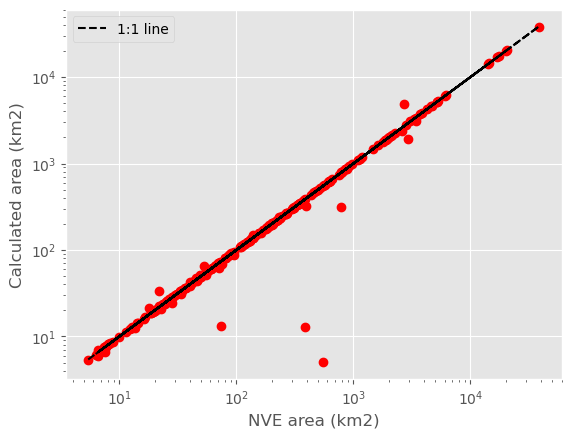

In [11]:
# Check calculated areas match NVE areas
plt.plot(cat_gdf["nve_area_km2"], cat_gdf["cat_area_km2"], "ro")
plt.plot(cat_gdf["nve_area_km2"], cat_gdf["nve_area_km2"], "k--", label="1:1 line")
plt.xlabel("NVE area (km2)")
plt.ylabel("Calculated area (km2)")
plt.xscale('log')
plt.yscale('log')
plt.legend()

### 2.2. Land cover proportions

From AR50.

**Results are saved, so the main code block below does not need re-running unless the query parameters are changed.**

In [12]:
# %%time

# print("Reading AR50...")
# ar50_gdb = r"/home/jovyan/shared/common/teotil3/core_data/land_cover/nibio_ar50.gdb"
# ar50_gdf = gpd.read_file(ar50_gdb, driver="fileGDB", layer="org_ar_ar50_flate")

# print("Reclassifying...")
# # Use TEOTIL class names
# land_class_csv = r"https://raw.githubusercontent.com/NIVANorge/teotil3/main/data/ar50_artype_classes.csv"
# artype_df = pd.read_csv(land_class_csv)
# ar50_gdf = pd.merge(ar50_gdf, artype_df, how="left", on="artype")
# ar50_gdf = ar50_gdf[["teotil", "geometry"]]

# print("Reprojecting to equal area...")
# cat_gdf_cea = cat_gdf.to_crs({"proj": "cea"})
# ar50_gdf_cea = ar50_gdf.to_crs({"proj": "cea"})

# print("Intersecting polygons...")
# int_gdf = gpd.overlay(
#     cat_gdf_cea, ar50_gdf_cea, how="intersection", keep_geom_type=True
# )
# int_gdf["area_km2"] = int_gdf["geometry"].area / 1e6

# print("Aggregating...")
# lc_df = int_gdf.groupby(["station_id", "teotil"]).sum(numeric_only=True)["area_km2"]
# lc_df = lc_df.unstack("teotil")
# lc_df.columns = [f"a_{i}_km2" for i in lc_df.columns]
# lc_df.reset_index(inplace=True)
# lc_df.columns.name = ""
# cat_gdf = pd.merge(cat_gdf, lc_df, on="station_id", how="left")

# # Fill NaN with 0
# cols = [
#     "a_agri_km2",
#     "a_glacier_km2",
#     "a_lake_km2",
#     "a_sea_km2",
#     "a_upland_km2",
#     "a_urban_km2",
#     "a_wood_km2",
# ]
# for col in cols:
#     if col in cat_gdf.columns:
#         cat_gdf[col] = cat_gdf[col].fillna(0)
#     else:
#         cat_gdf[col] = 0

# # Calculate 'other'
# cat_gdf["a_other_km2"] = (
#     cat_gdf["cat_area_km2"]
#     - cat_gdf["a_agri_km2"]
#     - cat_gdf["a_glacier_km2"]
#     - cat_gdf["a_lake_km2"]
#     - cat_gdf["a_sea_km2"]
#     - cat_gdf["a_upland_km2"]
#     - cat_gdf["a_urban_km2"]
#     - cat_gdf["a_wood_km2"]
# ).clip(lower=0)

# # Calculate percentages
# cols = [
#     "a_agri_km2",
#     "a_glacier_km2",
#     "a_lake_km2",
#     "a_sea_km2",
#     "a_upland_km2",
#     "a_urban_km2",
#     "a_wood_km2",
#     "a_other_km2",
# ]
# for col in cols:
#     pct_col = col.replace("_km2", "_pct")
#     cat_gdf[pct_col] = 100 * cat_gdf[col] / cat_gdf["cat_area_km2"]

# # Move 'geometry' to end
# cols = cat_gdf.columns.tolist()
# cols.remove("geometry")
# cols.append("geometry")
# cat_gdf = cat_gdf[cols]

# # Save
# gpkg_path = (
#     r"/home/jovyan/shared/common/JES/mjosa_water_temp/water_temp_catchments.gpkg"
# )
# cat_gdf.to_file(
#     gpkg_path, layer="water_temp_catchments_with_land_cover", driver="GPKG", index=False
# )

In [13]:
# Read saved data for speed
gpkg_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/water_temp_catchments.gpkg"
)
cat_gdf = gpd.read_file(gpkg_path, layer="water_temp_catchments_with_land_cover")
cat_gdf.head()

,station_id,station_name,latitude,longitude,utm33_east,utm33_north,elevation_m,river_name,kommune_nr,kommune_name,...,a_wood_km2,a_agri_pct,a_glacier_pct,a_lake_pct,a_sea_pct,a_upland_pct,a_urban_pct,a_wood_pct,a_other_pct,geometry
0,1.200.0,Lierelv,59.92038,11.53180,306146,6647624,134,Haldenvassdraget,3226.0,Aurskog-Høland,...,99.216395,16.474277,0.000000,3.495580,0.0,3.679917,2.249000,74.101225,0.0,"MULTIPOLYGON (((306720 6664200, 306720 6664160..."
1,1.41.0,Lognselva,59.80011,11.44331,300484,6634505,148,Haldenvassdraget,3226.0,Aurskog-Høland,...,15.704579,14.618796,0.000000,2.829018,0.0,4.760876,1.706502,76.084808,0.0,"MULTIPOLYGON (((300600 6642960, 300600 6642880..."
2,102.1.0,Hildreelv,62.60018,6.34442,56566,6970861,37,Hildreelva,1580.0,Haram,...,4.736111,0.860123,0.000000,6.315868,0.0,59.491159,0.000000,33.332851,0.0,"MULTIPOLYGON (((56400 6970920, 56400 6970880, ..."
3,103.12.0,Verma kraftstasjon,62.34783,8.05015,140646,6932269,167,Rauma,1539.0,Rauma,...,144.204442,1.093539,2.631335,3.584505,0.0,75.874690,0.307825,16.508105,0.0,"MULTIPOLYGON (((144200 6933440, 144200 6933400..."
4,103.3.0,Rauma v/Stuguflåten,62.27660,8.15311,145115,6923797,521,Rauma,3432.0,Lesja,...,71.351075,2.027724,2.475375,3.395578,0.0,72.450546,0.682513,18.968265,0.0,"MULTIPOLYGON (((148000 6932760, 148000 6932720..."


### 2.3. Gridded catchment data

The code below uses the GTS API to get modelled water discharge, snow melt and air temperature data for each site for the period where water temperatures are measured. 

In [14]:
pars = ["tm", "rr", "gwb_q", "qtt"]
max_retries = 5
n_samp = 300
temp_dir = r"/home/jovyan/shared/common/JES/mjosa_water_temp/data_by_site"

# Filter stations and data to just catchments with land cover properties
stn_ids = cat_gdf["station_id"].unique().tolist()
stn_df = stn_df.query("station_id in @stn_ids")
df = df.query("station_id in @stn_ids")
assert (
    len(stn_ids)
    == len(stn_df["station_id"].unique().tolist())
    == len(df["station_id"].unique().tolist())
)

# Loop over time series
for stn_id, val_df in df.groupby("station_id"):
    # print(stn_id)
    # Skip if already processed
    fname = stn_id.replace(".", "-")
    csv_path = os.path.join(temp_dir, f"{fname}.csv")
    if os.path.isfile(csv_path):
        # print("  Already processed.")
        continue
    retries = 0
    while retries < max_retries:
        try:
            # print("  Processing.")
            stn_gdf = cat_gdf.query("station_id == @stn_id").copy()
            cat_area = stn_gdf.iloc[0]["cat_area_km2"]
            val_df = val_df.dropna(subset="water_temp_c")
            st_dt = val_df["date"].min().strftime("%Y-%m-%d")
            end_dt = val_df["date"].max().strftime("%Y-%m-%d")
            if st_dt < end_dt:
                stat_df = utils.get_nve_gts_api_aggregated_time_series(
                    stn_gdf,
                    pars,
                    st_dt,
                    end_dt,
                    id_col="station_id",
                    n_samp=n_samp,
                    random_state=42,
                )
                stat_df["unit"] = stat_df["unit"].replace({"Celcius": "c"})
                stat_df["par"] = "gts_avg_" + stat_df["par"] + "_" + stat_df["unit"]
                stat_df = stat_df.set_index(["datetime", "par"])["value_mean"].unstack(
                    "par"
                )
                stat_df.columns.name = ""
                stat_df = stat_df.resample("D").mean()
                stat_df["date"] = stat_df.index
                stat_df = stat_df.reset_index(drop=True)
                stat_df["gts_mod_discharge_m3ps"] = (
                    1e6 * cat_area * stat_df["gts_avg_gwb_q_mm"] / (1000 * 24 * 60 * 60)
                )
                val_df = pd.merge(val_df, stat_df, how="outer", on="date")                
                val_df['station_id'] = val_df['station_id'].ffill().bfill()
                val_df['station_name'] = val_df['station_name'].ffill().bfill()
                val_df.to_csv(csv_path, index=False)
            break
        except URLError as e:
            retries += 1
            time.sleep(5)

# Combine all data
flist = glob.glob(os.path.join(temp_dir, "*.csv"))
df = pd.concat([pd.read_csv(fpath) for fpath in flist], axis="rows")
df["date"] = pd.to_datetime(df["date"])

# Check completeness
stn_df = cat_gdf.drop(columns='geometry')
stn_ids = stn_df["station_id"].unique().tolist()
processed = df['station_id'].unique().tolist()
missing = set(stn_ids) - set(processed)
print(f"Data available for {len(processed)} stations ({len(df) / 1e6} million records in total).")
print(f"Data has not been downloaded for {len(missing)} station(s):")
assert len(missing) + len(processed) == len(stn_ids)
print(missing)

# Filter metadata to match processed
stn_df = stn_df.query("station_id in @processed")
cat_gdf = cat_gdf.query("station_id in @processed")

# Save
csv_path = r"/home/jovyan/shared/common/JES/mjosa_water_temp/station_properties.csv"
stn_df.to_csv(csv_path, index=False)
csv_path = r"/home/jovyan/shared/common/JES/mjosa_water_temp/merged_data.csv"
df.to_csv(csv_path, index=False)
gpkg_path = (
    r"/home/jovyan/shared/common/JES/mjosa_water_temp/water_temp_catchments.gpkg"
)
cat_gdf.to_file(
    gpkg_path, layer="catchments_with_land_cover_and_data", driver="GPKG", index=False
)

df.head()

Data available for 527 stations (3.285879 million records in total).
Data has not been downloaded for 1 station(s):
{'16.261.1'}


,station_id,station_name,date,water_temp_c,discharge_m3ps,gts_avg_gwb_q_mm,gts_avg_qtt_mm,gts_avg_rr_mm,gts_avg_tm_c,gts_mod_discharge_m3ps
0,15.115.0,Numedalslågen v/Brufoss,1990-06-05,11.81234,NaN,7.933667,7.170000,2.927333,7.414667,442.849449
1,15.115.0,Numedalslågen v/Brufoss,1990-06-06,11.88484,NaN,8.032333,5.893333,0.771000,9.161333,448.356925
2,15.115.0,Numedalslågen v/Brufoss,1990-06-07,12.02386,NaN,8.117667,5.333333,0.270000,9.877667,453.120147
3,15.115.0,Numedalslågen v/Brufoss,1990-06-08,12.18458,NaN,8.307333,9.223333,4.604333,8.845000,463.707154
4,15.115.0,Numedalslågen v/Brufoss,1990-06-09,12.36245,NaN,8.231333,4.170000,0.005000,8.592000,459.464908
